In [ ]:
# ============================================
# ASSIGNMENT 6 - METHOD 1: CYCLEGAN
# ============================================

# Download the official CycleGAN project from GitHub
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

# Move into the CycleGAN project folder
%cd pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 12.68 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix


In [ ]:
# ============================================
# INSTALL REQUIRED LIBRARIES
# ============================================

# Install libraries required to run CycleGAN
!pip install -q torch torchvision dominate visdom

In [ ]:
# ============================================
# CHECK CYCLEGAN INSTALLATION
# ============================================

import os

# Display the current working directory
print("Current directory:")
print(os.getcwd())

# Display files and folders inside the CycleGAN project
print("\nCycleGAN files:")
print(os.listdir())

Current directory:
/content/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix

CycleGAN files:
['README.md', 'datasets', '.gitignore', 'pix2pix.ipynb', '.replit', 'LICENSE', 'models', 'docs', 'CycleGAN.ipynb', 'imgs', 'util', 'test.py', 'options', 'environment.yml', '.git', 'scripts', 'train.py', 'data']


In [ ]:
# ============================================
# DOWNLOAD PRETRAINED CYCLEGAN MODEL
# ============================================

# Download the pretrained CycleGAN model
# This model converts landscape photographs
# into Monet-style paintings

!bash ./scripts/download_cyclegan_model.sh style_monet

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2026-10-01 09:23:25--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  63.7MB/s    in 0.7s    

2026-10-01 09:23:26 (63.7 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’ saved [45575747/45575747]



In [ ]:
# ============================================
# UPLOAD ORIGINAL IMAGE
# ============================================

from google.colab import files

# Open the file upload window
uploaded = files.upload()

Saving orginal.jpg to orginal.jpg


In [ ]:
# ============================================
# PREPARE INPUT IMAGE
# ============================================

import os
import shutil

# Create a folder for the input image
os.makedirs("my_input", exist_ok=True)

# Get the name of the uploaded file
filename = list(uploaded.keys())[0]

# Copy the uploaded image into the CycleGAN input folder
# We rename it to original.jpg to keep the path simple
shutil.copy(filename, "my_input/original.jpg")

# Confirm that the image was copied successfully
print("Uploaded file:", filename)
print("Saved as: my_input/original.jpg")

Uploaded file: orginal.jpg
Saved as: my_input/original.jpg


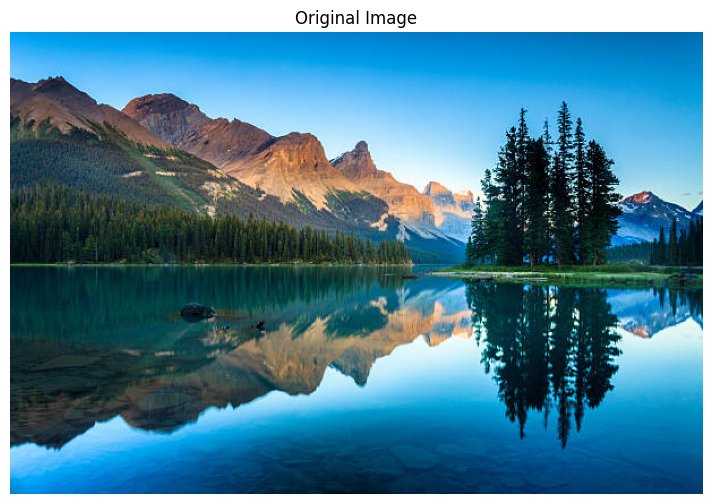

In [ ]:
# ============================================
# DISPLAY ORIGINAL IMAGE
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

# Open the uploaded image
img = Image.open("my_input/original.jpg")

# Display the image
plt.figure(figsize=(10, 6))
plt.imshow(img)

# Add title
plt.title("Original Image")

# Hide axis numbers
plt.axis("off")

# Show image
plt.show()

In [ ]:
# ============================================
# APPLY CYCLEGAN STYLE TRANSFER
# ============================================

# Use the pretrained Monet CycleGAN model
# to transform the landscape photograph
# into a Monet-style painting

!python test.py \
    --dataroot ./my_input \
    --name style_monet_pretrained \
    --model test \
    --no_dropout \
    --results_dir ./cycleGAN_results

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./my_input                    	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [ ]:
# ============================================
# FIND CYCLEGAN OUTPUT
# ============================================

import os

# Search for generated images
for root, folders, files_list in os.walk("cycleGAN_results"):
    for file in files_list:
        print(os.path.join(root, file))

cycleGAN_results/style_monet_pretrained/test_latest/index.html
cycleGAN_results/style_monet_pretrained/test_latest/images/original_real.png
cycleGAN_results/style_monet_pretrained/test_latest/images/original_fake.png


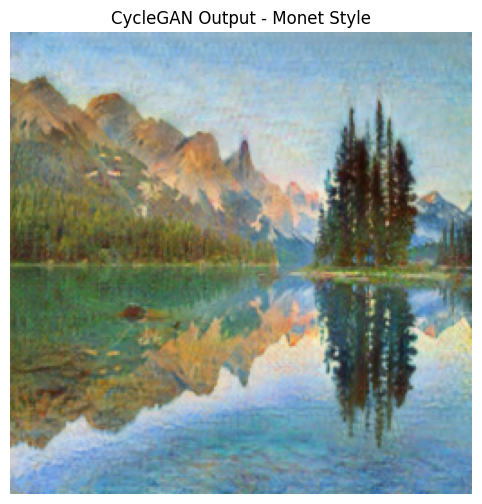

In [ ]:
# ============================================
# DISPLAY CYCLEGAN OUTPUT
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

# Load the CycleGAN generated image
cyclegan_output = Image.open(
    "cycleGAN_results/style_monet_pretrained/test_latest/images/original_fake.png"
)

# Display the generated image
plt.figure(figsize=(10, 6))
plt.imshow(cyclegan_output)

# Add title
plt.title("CycleGAN Output - Monet Style")

# Hide axis numbers
plt.axis("off")

# Show image
plt.show()

In [ ]:
# ============================================
# SAVE CYCLEGAN OUTPUT
# ============================================

# Save the generated image with a simple filename
cyclegan_output.save("cycleGAN_output.png")

print("CycleGAN output saved successfully!")
print("File name: cycleGAN_output.png")

CycleGAN output saved successfully!
File name: cycleGAN_output.png


In [ ]:
# ============================================
# ASSIGNMENT 6 - METHOD 2: NEURAL STYLE TRANSFER
# ============================================

# Import PyTorch for deep learning
import torch
import torch.nn as nn
import torch.optim as optim

# Import torchvision for the pretrained VGG19 model
import torchvision.models as models
import torchvision.transforms as transforms

# Import image processing libraries
from PIL import Image
import matplotlib.pyplot as plt

# Import numerical library
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ============================================
# SELECT COMPUTING DEVICE
# ============================================

# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [ ]:
# ============================================
# DOWNLOAD STYLE PAINTING
# ============================================

# Remove the broken style image if it exists
import os

if os.path.exists("style.jpg"):
    os.remove("style.jpg")

# Download a valid copy of Van Gogh's Starry Night
!wget -q -O style.jpg "https://commons.wikimedia.org/wiki/Special:Redirect/file/Vincent_van_Gogh_Starry_Night.jpg"

# Check that the file was downloaded
print("Style image downloaded!")
print("File size:", os.path.getsize("style.jpg"), "bytes")

Style image downloaded!
File size: 1262868 bytes


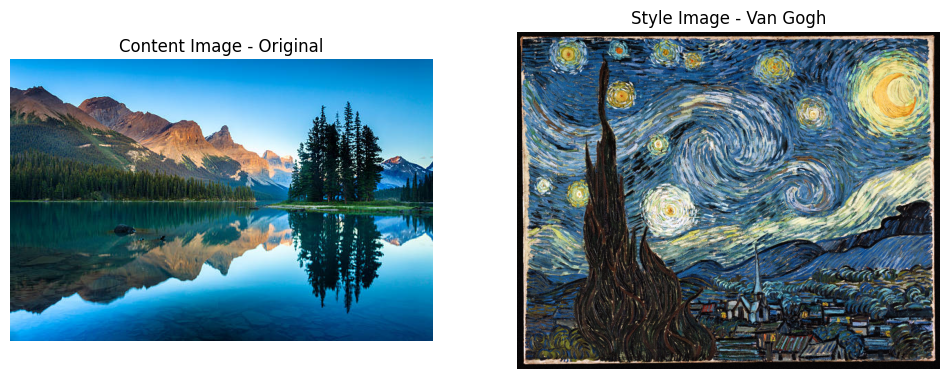

In [ ]:
# ============================================
# LOAD CONTENT AND STYLE IMAGES
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

# Load your original landscape image
content_image = Image.open("my_input/original.jpg").convert("RGB")

# Load the painting
style_image = Image.open("style.jpg").convert("RGB")

# Display both images
plt.figure(figsize=(12, 5))

# Original landscape
plt.subplot(1, 2, 1)
plt.imshow(content_image)
plt.title("Content Image - Original")
plt.axis("off")

# Van Gogh painting
plt.subplot(1, 2, 2)
plt.imshow(style_image)
plt.title("Style Image - Van Gogh")
plt.axis("off")

plt.show()

In [ ]:
# ============================================
# PREPARE IMAGES FOR VGG19
# ============================================

import torch
import torchvision.transforms as transforms

# Use a smaller image size so the process runs faster
image_size = 256

# Convert images into tensors
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# Prepare the original image
content = transform(content_image).unsqueeze(0).to(device)

# Prepare the painting
style = transform(style_image).unsqueeze(0).to(device)

print("Images prepared successfully!")
print("Content image shape:", content.shape)
print("Style image shape:", style.shape)

Images prepared successfully!
Content image shape: torch.Size([1, 3, 256, 256])
Style image shape: torch.Size([1, 3, 256, 256])


In [ ]:
# ============================================
# LOAD PRETRAINED VGG19
# ============================================

import torchvision.models as models

# Load pretrained VGG19
vgg = models.vgg19(
    weights=models.VGG19_Weights.DEFAULT
)

# Use only the feature extraction layers
vgg = vgg.features.to(device).eval()

# Freeze VGG19 parameters
# We are NOT training VGG19
for parameter in vgg.parameters():
    parameter.requires_grad = False

print("Pretrained VGG19 loaded successfully!")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 67.0MB/s]


Pretrained VGG19 loaded successfully!


In [ ]:
# ============================================
# DEFINE CONTENT AND STYLE LAYERS
# ============================================

# Layer used to capture the content
content_layers = ['21']

# Layers used to capture artistic style
style_layers = ['0', '5', '10', '19', '28']

print("Content layer:", content_layers)
print("Style layers:", style_layers)

Content layer: ['21']
Style layers: ['0', '5', '10', '19', '28']


In [ ]:
# ============================================
# EXTRACT VGG19 FEATURES
# ============================================

def get_features(image):
    """
    Extract content and style features
    from the VGG19 network.
    """

    features = {}

    x = image

    # Pass image through VGG19 layers
    for name, layer in vgg._modules.items():

        x = layer(x)

        # Save important feature maps
        if name in style_layers or name in content_layers:
            features[name] = x

    return features


# Extract features from original landscape
content_features = get_features(content)

# Extract features from Van Gogh painting
style_features = get_features(style)

print("Content and style features extracted successfully!")

Content and style features extracted successfully!


In [ ]:
# ============================================
# CALCULATE STYLE REPRESENTATION
# ============================================

def gram_matrix(tensor):
    """
    Calculate the Gram Matrix.
    It represents the visual style
    of an image.
    """

    # Get dimensions
    batch, channels, height, width = tensor.size()

    # Flatten the image features
    features = tensor.view(channels, height * width)

    # Calculate Gram Matrix
    gram = torch.mm(features, features.t())

    # Normalize the Gram Matrix
    return gram / (channels * height * width)


# Calculate style representation
style_grams = {
    layer: gram_matrix(style_features[layer])
    for layer in style_layers
}

print("Style representation calculated successfully!")

Style representation calculated successfully!


In [ ]:
# ============================================
# CREATE IMAGE FOR STYLE TRANSFER
# ============================================

# Start with a copy of the original landscape
# The generated image will gradually learn the painting style

target = content.clone().requires_grad_(True)

print("Generated image initialized from original landscape.")

Generated image initialized from original landscape.


In [ ]:
# ============================================
# APPLY VGG-BASED NEURAL STYLE TRANSFER
# ============================================

import torch.optim as optim

# Optimizer updates the generated image
optimizer = optim.Adam([target], lr=0.02)

# Number of optimization steps
steps = 300

# Weight given to content
content_weight = 1

# Weight given to artistic style
style_weight = 100000

# Start optimization
for step in range(steps):

    # Extract features from generated image
    target_features = get_features(target)

    # ----------------------------------------
    # CONTENT LOSS
    # ----------------------------------------

    # Keeps the landscape structure similar
    content_loss = torch.mean(
        (target_features['21'] - content_features['21']) ** 2
    )

    # ----------------------------------------
    # STYLE LOSS
    # ----------------------------------------

    style_loss = 0

    for layer in style_layers:

        # Calculate Gram Matrix of generated image
        target_gram = gram_matrix(target_features[layer])

        # Compare generated style with painting style
        style_loss += torch.mean(
            (target_gram - style_grams[layer]) ** 2
        )

    # ----------------------------------------
    # TOTAL LOSS
    # ----------------------------------------

    total_loss = (
        content_weight * content_loss +
        style_weight * style_loss
    )

    # Remove previous gradients
    optimizer.zero_grad()

    # Calculate gradients
    total_loss.backward()

    # Update generated image
    optimizer.step()

    # Keep pixel values between 0 and 1
    with torch.no_grad():
        target.clamp_(0, 1)

    # Display progress every 50 steps
    if step % 50 == 0:
        print(
            f"Step {step}/{steps} | "
            f"Content Loss: {content_loss.item():.4f} | "
            f"Style Loss: {style_loss.item():.4f}"
        )

print("Neural Style Transfer completed!")

Step 0/300 | Content Loss: 0.1537 | Style Loss: 0.0000
Step 50/300 | Content Loss: 0.1612 | Style Loss: 0.0000
Step 100/300 | Content Loss: 0.1509 | Style Loss: 0.0000
Step 150/300 | Content Loss: 0.1513 | Style Loss: 0.0000
Step 200/300 | Content Loss: 0.1465 | Style Loss: 0.0000
Step 250/300 | Content Loss: 0.1463 | Style Loss: 0.0000
Neural Style Transfer completed!


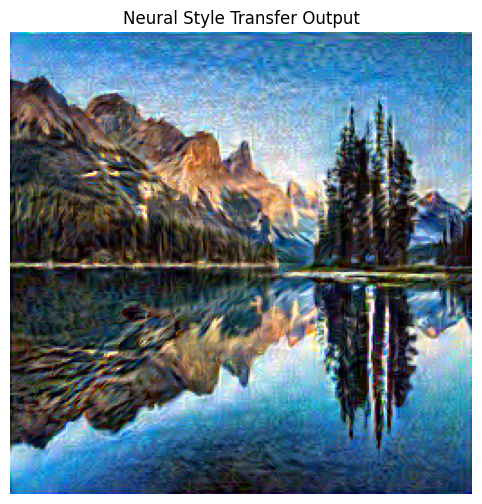

In [41]:
# ============================================
# DISPLAY NEURAL STYLE TRANSFER OUTPUT
# ============================================

# Move generated image from GPU to CPU
output = target.detach().cpu().squeeze(0)

# Change tensor format to image format
output = output.permute(1, 2, 0).numpy()

# Display the result
plt.figure(figsize=(10, 6))

plt.imshow(output)

plt.title("Neural Style Transfer Output")

plt.axis("off")

plt.show()

In [42]:
# ============================================
# SAVE NEURAL STYLE TRANSFER OUTPUT
# ============================================

from PIL import Image
import numpy as np

# Convert the generated array into an image
output_image = Image.fromarray(
    (output * 255).astype(np.uint8)
)

# Save the result
output_image.save("neural_style_output.png")

print("Neural Style Transfer output saved!")
print("File: neural_style_output.png")

Neural Style Transfer output saved!
File: neural_style_output.png


In [43]:
# ============================================
# CHECK FINAL ASSIGNMENT FILES
# ============================================

import os

# List the three required images
files_to_check = [
    "my_input/original.jpg",
    "cycleGAN_output.png",
    "neural_style_output.png"
]

for file in files_to_check:
    if os.path.exists(file):
        print("✅ Found:", file)
    else:
        print("❌ Missing:", file)

✅ Found: my_input/original.jpg
✅ Found: cycleGAN_output.png
✅ Found: neural_style_output.png


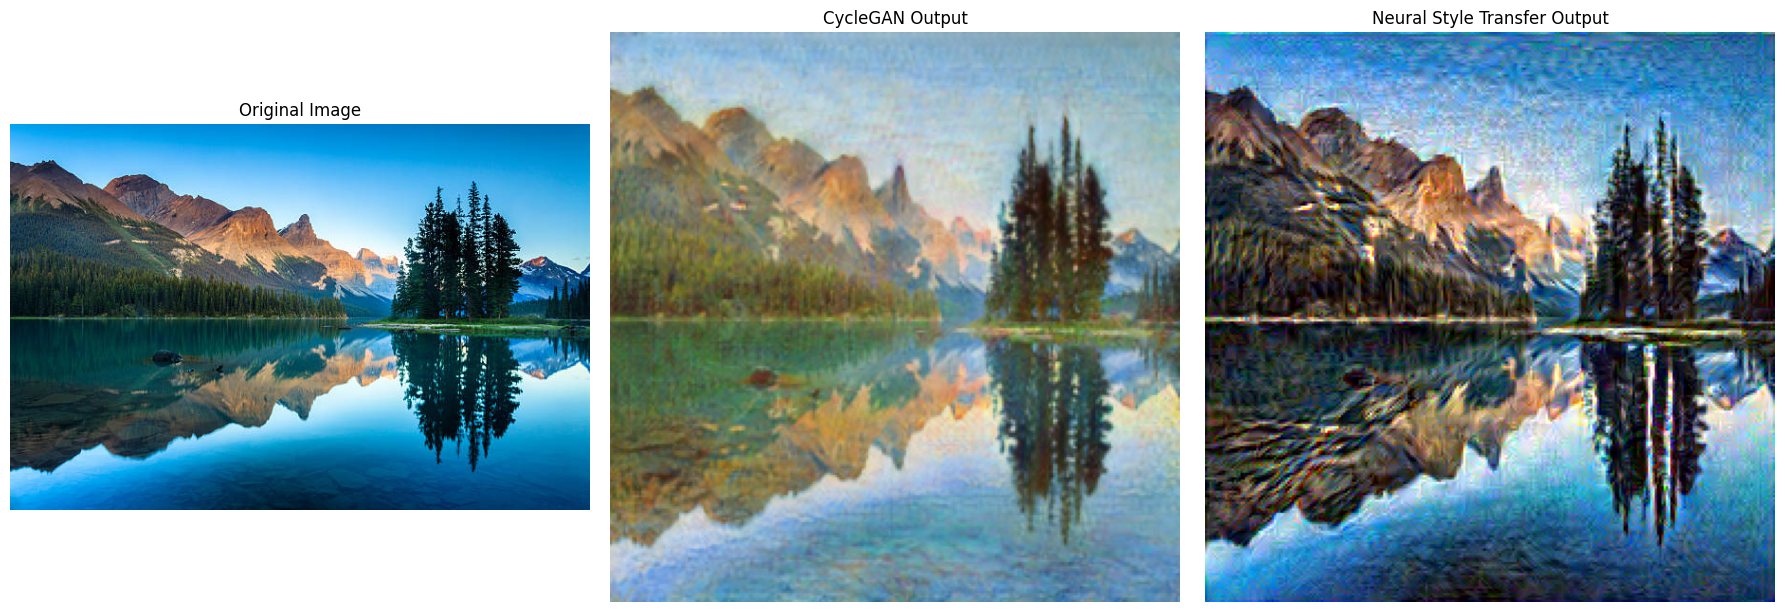

✅ Side-by-side comparison saved!


In [44]:
# ============================================
# CREATE SIDE-BY-SIDE COMPARISON
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

# Load all three images
original = Image.open("my_input/original.jpg")
cyclegan = Image.open("cycleGAN_output.png")
neural_style = Image.open("neural_style_output.png")

# Create side-by-side figure
plt.figure(figsize=(18, 6))

# Original
plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

# CycleGAN
plt.subplot(1, 3, 2)
plt.imshow(cyclegan)
plt.title("CycleGAN Output")
plt.axis("off")

# Neural Style Transfer
plt.subplot(1, 3, 3)
plt.imshow(neural_style)
plt.title("Neural Style Transfer Output")
plt.axis("off")

plt.tight_layout()

# Save comparison
plt.savefig(
    "assignment6_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ Side-by-side comparison saved!")

In [45]:
# ============================================
# CREATE ASSIGNMENT 6 DOCUMENT
# ============================================

!pip install -q python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 8.8 MB/s eta 0:00:00


In [46]:
# ============================================
# CREATE FINAL DOCX
# ============================================

from docx import Document
from docx.shared import Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Create document
doc = Document()

# --------------------------------------------
# TITLE
# --------------------------------------------

title = doc.add_heading(
    "ASSIGNMENT 6",
    level=1
)

title.alignment = WD_ALIGN_PARAGRAPH.CENTER

subtitle = doc.add_paragraph(
    "Applying AI-Based Style Transfer to an Image"
)

subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

# --------------------------------------------
# OBJECTIVE
# --------------------------------------------

doc.add_heading("Objective", level=2)

doc.add_paragraph(
    "The objective of this assignment is to compare two "
    "different methods of image style transfer: CycleGAN "
    "and VGG-based Neural Style Transfer."
)

# --------------------------------------------
# ORIGINAL IMAGE
# --------------------------------------------

doc.add_heading("1. Original Image", level=2)

doc.add_picture(
    "my_input/original.jpg",
    width=Inches(6)
)

# --------------------------------------------
# CYCLEGAN OUTPUT
# --------------------------------------------

doc.add_heading("2. CycleGAN Output", level=2)

doc.add_picture(
    "cycleGAN_output.png",
    width=Inches(6)
)

# --------------------------------------------
# NEURAL STYLE TRANSFER OUTPUT
# --------------------------------------------

doc.add_heading(
    "3. Neural Style Transfer Output",
    level=2
)

doc.add_picture(
    "neural_style_output.png",
    width=Inches(6)
)

# --------------------------------------------
# SIDE-BY-SIDE COMPARISON
# --------------------------------------------

doc.add_heading(
    "4. Side-by-Side Comparison",
    level=2
)

doc.add_picture(
    "assignment6_comparison.png",
    width=Inches(6.5)
)

# --------------------------------------------
# WRITTEN COMPARISON
# --------------------------------------------

doc.add_heading(
    "5. Written Comparison",
    level=2
)

comparison = (
    "Neural Style Transfer preserved the original content better "
    "because the mountains, lake, trees, and overall structure "
    "remained recognizable. CycleGAN produced a stronger overall "
    "domain/style transformation by converting the landscape into "
    "a painting-like appearance. Neural Style Transfer applied the "
    "visual characteristics of the selected painting while maintaining "
    "the original scene structure more closely. CycleGAN uses cycle "
    "consistency, which encourages an image translated between two "
    "domains to retain important information when mapped back to "
    "the original domain."
)

doc.add_paragraph(comparison)

# --------------------------------------------
# SAVE DOCUMENT
# --------------------------------------------

doc.save("Assignment_6_Style_Transfer.docx")

print("✅ FINAL DOCUMENT CREATED!")
print("File: Assignment_6_Style_Transfer.docx")

✅ FINAL DOCUMENT CREATED!
File: Assignment_6_Style_Transfer.docx


In [47]:
# ============================================
# DOWNLOAD FINAL ASSIGNMENT
# ============================================

from google.colab import files

files.download("Assignment_6_Style_Transfer.docx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
from google.colab import files
files.download("my_input/original.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
from google.colab import files
files.download("cycleGAN_output.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
from google.colab import files
files.download("neural_style_output.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>